In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mplhep as hep
from iminuit import Minuit
from iminuit.cost import LeastSquares
import pickle
import uproot as ur
import matplotlib.colors as mcolors
import numpy as np
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline
from scipy.signal import find_peaks

In [3]:
sim_df = pd.read_pickle("CRYmuon_DF.pkl")

In [4]:
print(np.array(sim_df["energy_GeV"]))

[0. 0. 0. ... 0. 0. 0.]


0.0012071771771771773


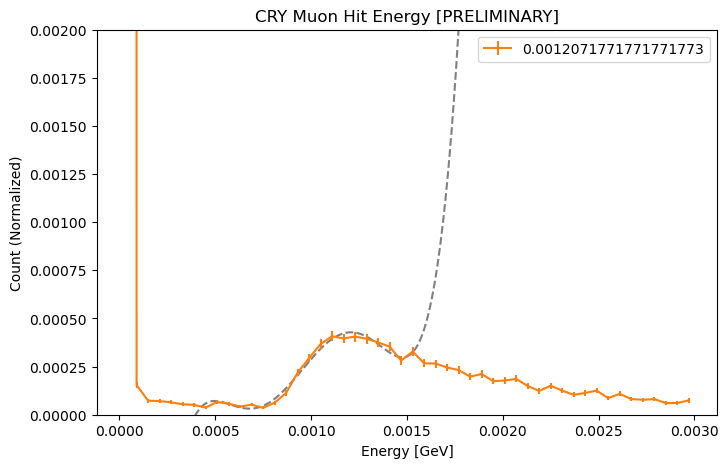

In [7]:
def configure_plotting():
    plt.rcParams['figure.facecolor'] = 'white'
    plt.rcParams['savefig.facecolor'] = 'white'
    plt.rcParams['savefig.bbox'] = 'tight'
    hep.style.use(hep.style.CMS)
def extract_all_energies(df, energy_col='energy_GeV'):
    # Drop NaNs and convert to NumPy array
    energies = df[energy_col].dropna().to_numpy()
    return energies
    return energy_sum.values
def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))
    
def fit_and_plot(hit_energy, label, color, hist_range=(0, 0.003), min_peak_x=0.0003):
    counts, bin_edges = np.histogram(hit_energy, bins=50, range=hist_range)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # Normalize
    total = np.sum(counts)
    counts = counts / total
    errors = np.sqrt(counts * total) / total  # Poisson errors normalized
    mask = (bin_centers > 0.0005) & (bin_centers < 0.0015)
    spline = UnivariateSpline(bin_centers[mask], counts[mask], s=500, k=5)
    interp_x = np.linspace(bin_centers[0], bin_centers[-1], 1000)
    interp_y = spline(interp_x)

    # Find MIP peak
    peaks, properties = find_peaks(interp_y, height=0)
    peak_positions = interp_x[peaks]
    peak_heights = properties['peak_heights']

    valid_indices = [j for j, x in enumerate(peak_positions) if x > min_peak_x]
    if valid_indices:
        max_idx = valid_indices[np.argmax([peak_heights[j] for j in valid_indices])]
        mip_peak = peak_positions[max_idx]
    else:
        mip_peak = 0
    plt.plot(interp_x, interp_y, linestyle="--", color='gray')
    # Plot data with error bars
    plt.errorbar(bin_centers, counts, yerr=errors, fmt='-', color=color, label=mip_peak)
    print(mip_peak)
    plt.legend()
# Run for both data and sim
hit_energy_sim = extract_all_energies(sim_df)

plt.figure(figsize=(8, 5))
fit_and_plot(hit_energy_sim, "Sim", color='tab:orange')
plt.ylim(0,0.002)

#plt.legend(fontsize=15, loc="upper right")
plt.title("CRY Muon Hit Energy [PRELIMINARY]")
plt.xlabel("Energy [GeV]")
plt.ylabel("Count (Normalized)")
plt.show()


0.04351095345345346


/var/folders/78/mghq7lpd3rbcbtn434kbwgdw0000gn/T/ipykernel_1689/4173492968.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=15, loc="upper right")


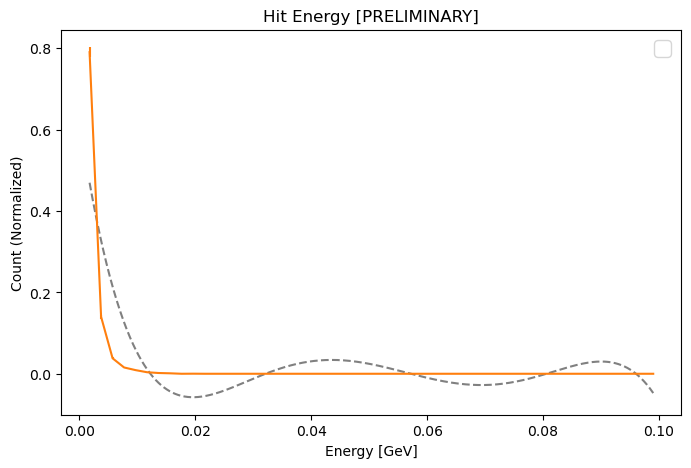

0.0008648223223223224

In [5]:

sim_df = pd.read_pickle("CRYmuon_DF.pkl")
def configure_plotting():
    plt.rcParams['figure.facecolor'] = 'white'
    plt.rcParams['savefig.facecolor'] = 'white'
    plt.rcParams['savefig.bbox'] = 'tight'
    hep.style.use(hep.style.CMS)
def extract_all_energies(df, energy_col='energy_GeV'):
    # Drop NaNs and convert to NumPy array
    energies = df[energy_col].dropna().to_numpy()
    return energies
    return energy_sum.values
def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))
    
def fit_and_plot(hit_energy, label, color, hist_range=(0.00075, 0.1), min_peak_x=0.0003):
    counts, bin_edges = np.histogram(hit_energy, bins=50, range=hist_range)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # Normalize
    total = np.sum(counts)
    counts = counts / total
    errors = np.sqrt(counts * total) / total  # Poisson errors normalized

    spline = UnivariateSpline(bin_centers, counts, s=500, k=5)
    interp_x = np.linspace(bin_centers[0], bin_centers[-1], 1000)
    interp_y = spline(interp_x)

    # Find MIP peak
    peaks, properties = find_peaks(interp_y, height=0)
    peak_positions = interp_x[peaks]
    peak_heights = properties['peak_heights']

    valid_indices = [j for j, x in enumerate(peak_positions) if x > min_peak_x]
    if valid_indices:
        max_idx = valid_indices[np.argmax([peak_heights[j] for j in valid_indices])]
        mip_peak = peak_positions[max_idx]
    else:
        mip_peak = 0
    plt.plot(interp_x, interp_y, linestyle="--", color='gray')
    # Plot data with error bars
    plt.errorbar(bin_centers, counts, yerr=errors, fmt='-', color=color)
    print(mip_peak)
# Run for both data and sim
hit_energy_sim = extract_all_energies(sim_df)

plt.figure(figsize=(8, 5))
fit_and_plot(hit_energy_sim, "Sim", color='tab:orange')
#plt.ylim(0,0.2)
plt.legend(fontsize=15, loc="upper right")
plt.title("Hit Energy [PRELIMINARY]")
plt.xlabel("Energy [GeV]")
plt.ylabel("Count (Normalized)")
plt.show()

0.0008648223223223224
